# Make time series plots of flow and exports for the three scenarios

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
# import datetime.datetime as datetime

In [2]:
#modified from code from expanse

In [4]:
# load the flux time series for each scenario
base=pd.read_csv('/global/scratch/users/jennaisrael/BayDeltaSCHISM/data/time_history/flux.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcp=pd.read_csv('/global/scratch/users/jennaisrael/expanse_scenario_files/DCP/data/time_history/flux_dcp_fixinterp.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor=pd.read_csv('/global/scratch/users/jennaisrael/expanse_scenario_files/reserves/data/time_history/flux_cor_fixinterp.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
base

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2006-10-01 00:00:00,-0.62,0.67,4.52,262.320007,120.830002,-94.860001,-0.0,-25.780001,-72.769997,-329.829987,0.690000,-0.00,2.48,-0.01,0.00
2006-10-01 00:15:00,-0.62,0.67,4.52,263.239990,120.820000,-94.860001,-0.0,-25.730000,-71.919998,-329.890015,-4.620000,-0.00,2.46,-0.01,0.00
2006-10-01 00:30:00,-0.62,0.66,4.52,263.410004,120.820000,-95.430000,-0.0,-25.690001,-73.339996,-330.239990,-8.100000,-0.00,2.46,-0.01,0.00
2006-10-01 00:45:00,-0.62,0.66,4.52,263.390015,120.820000,-94.860001,-0.0,-25.660000,-73.910004,-330.299988,-9.660000,-0.00,2.45,-0.01,0.00
2006-10-01 01:00:00,-0.62,0.66,4.52,263.350006,120.820000,-94.860001,-0.0,-25.629999,-73.910004,-330.649994,-10.650000,-0.00,2.45,-0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14 23:00:00,-0.76,0.00,3.40,1.010000,98.879997,-79.940002,-0.0,-76.169998,-144.699997,-1716.310059,-113.269997,-9.06,0.54,-5.10,1.17
2026-01-14 23:15:00,-0.74,0.00,3.42,3.000000,98.870003,-79.919998,-0.0,-76.180000,-144.699997,-1716.869995,-113.269997,-8.50,0.55,-5.04,1.18
2026-01-14 23:30:00,-0.74,0.00,3.44,7.780000,98.860001,-79.900002,-0.0,-76.180000,-144.130005,-1716.869995,-113.269997,-8.50,0.57,-5.10,1.20


In [6]:
# load the time series of tunnel exports
dcp_sinks=pd.read_csv('/global/scratch/users/jennaisrael/expanse_scenario_files/DCP/vsink_DCP_dated_single.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
tunnel=dcp_sinks['dcp_sink_1']*-1
tunnel

datetime
1999-12-01    0.645749
1999-12-02    1.721087
1999-12-03    2.633532
1999-12-04    3.423981
1999-12-05    4.123873
                ...   
2023-09-26         NaN
2023-09-27         NaN
2023-09-28         NaN
2023-09-29         NaN
2023-09-30         NaN
Name: dcp_sink_1, Length: 8705, dtype: float32

In [7]:
# resample to be daily
base=base.resample('D').mean()
dcp=dcp.resample('D').mean()
cor=cor.resample('D').mean()
dcp

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2017-01-01,-0.212677,0.486051,0.894939,165.117218,122.754448,-147.251907,-12.369093,-213.950150,-263.527466,-1313.604736,-113.267403,-1066.366699,5.789164,-3.286729,0.499348
2017-01-02,-0.265302,0.528348,0.972841,178.786133,123.986977,-166.778885,-22.526163,-237.913574,-271.571381,-1353.701050,-113.267403,-1177.127930,6.239809,-3.141646,0.542804
2017-01-03,-0.444490,0.584993,1.077116,190.139313,125.013268,-183.275375,-30.985580,-257.880646,-282.341156,-1407.385254,-113.267403,-1302.804688,6.613750,-9.149854,0.600994
2017-01-04,-1.348438,0.637412,1.173639,199.653152,125.876427,-197.436829,-38.102554,-274.689911,-292.310120,-1457.077515,-113.267403,-1393.143311,6.926661,-115.532753,0.654848
2017-01-05,-2.720062,0.682264,1.256210,207.687912,126.609116,-209.797470,-44.146435,-288.977448,-300.838745,-1499.589966,-113.267403,-1452.432251,7.190395,-35.627293,0.700925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-28,-9.078750,1.784479,0.025760,23.961042,48.238834,-57.580605,0.000000,-71.976486,-56.691353,-902.439087,-47.315418,0.000000,0.396094,-20.489292,0.444010
2021-12-29,-8.497761,1.570448,0.001240,0.171250,73.468071,-68.461876,0.000000,-55.672321,-55.465679,-812.193542,-49.463123,0.000000,0.396458,-19.107374,0.014375
2021-12-30,-10.388750,1.798344,0.000042,23.828228,73.369476,-70.243462,0.000000,-46.136604,-111.594925,-714.609192,-47.992813,0.000000,0.424844,-15.624427,0.000677


In [8]:
# calculate total inflows and exports
base['exports']=base.swp+base.cvp+base.ccc_rock+base.northbay+base.ccc_victoria+base.ccc_old
dcp['exports']=dcp.swp+dcp.cvp+dcp.ccc_rock+dcp.northbay+dcp.ccc_victoria+tunnel+dcp.ccc_old
cor['exports']=cor.swp+cor.cvp+cor.ccc_rock+cor.northbay+cor.ccc_victoria+cor.ccc_old

base['s_exports']=base.swp+base.cvp
dcp['s_exports']=dcp.swp+dcp.cvp
cor['s_exports']=cor.swp+cor.cvp


base['inf']=(base['sac']+base['east']+base['sjr']+base['yolo']+base['calaveras']+base['yolo_toedrain']+base['coyote']+base['napa']+base['american'])*-1
dcp['inf']=(dcp['sac']+dcp['east']+dcp['sjr']+dcp['yolo']+dcp['calaveras']+dcp['yolo_toedrain']+dcp['coyote']+dcp['napa']+dcp['american'])*-1
cor['inf']=(cor['sac']+cor['east']+cor['sjr']+cor['yolo']+cor['calaveras']+cor['yolo_toedrain']+cor['coyote']+cor['napa']+cor['american'])*-1

base['net']=base.inf-base.exports
dcp['net']=dcp.inf-dcp.exports
cor['net']=cor.inf-cor.exports

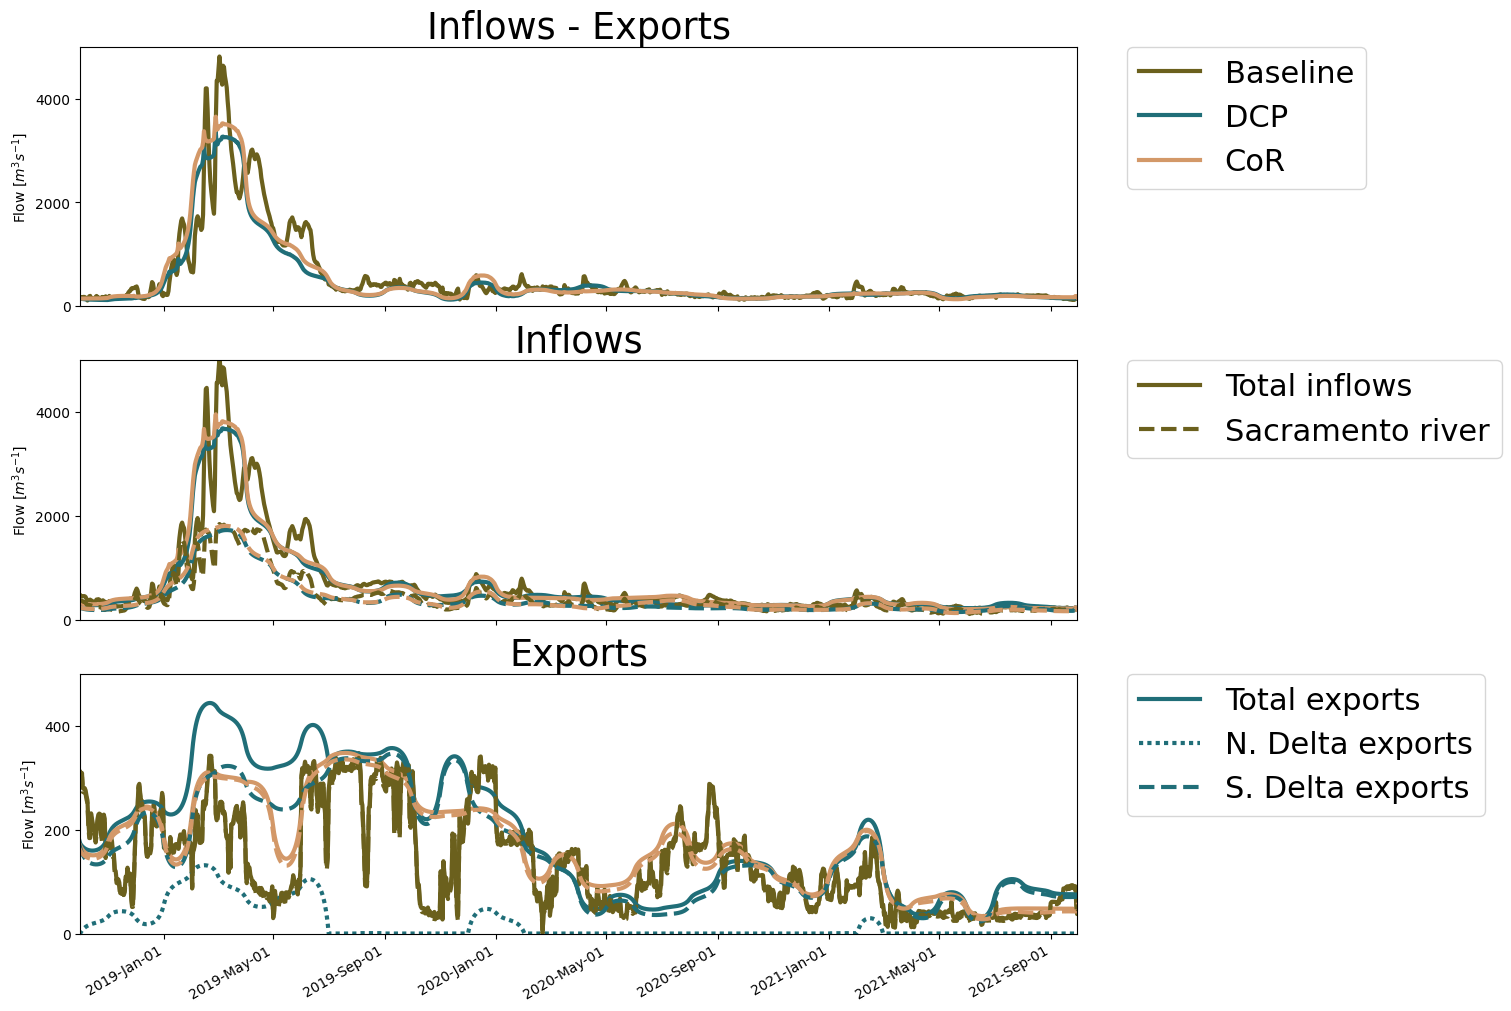

In [9]:
# make stacked plots 
fig, ax = plt.subplots(3,figsize=(15,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,5000)
ax[0].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
ax[1].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
ax[1].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,5000)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
ax[2].plot(dcp.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
ax[2].plot(cor.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

ax[2].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2021-9-30"))
ax[2].set_ylim(0,500)

ax[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2].xaxis.get_major_locator()))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/inflows_exports_scenarios_trim_feb.png')

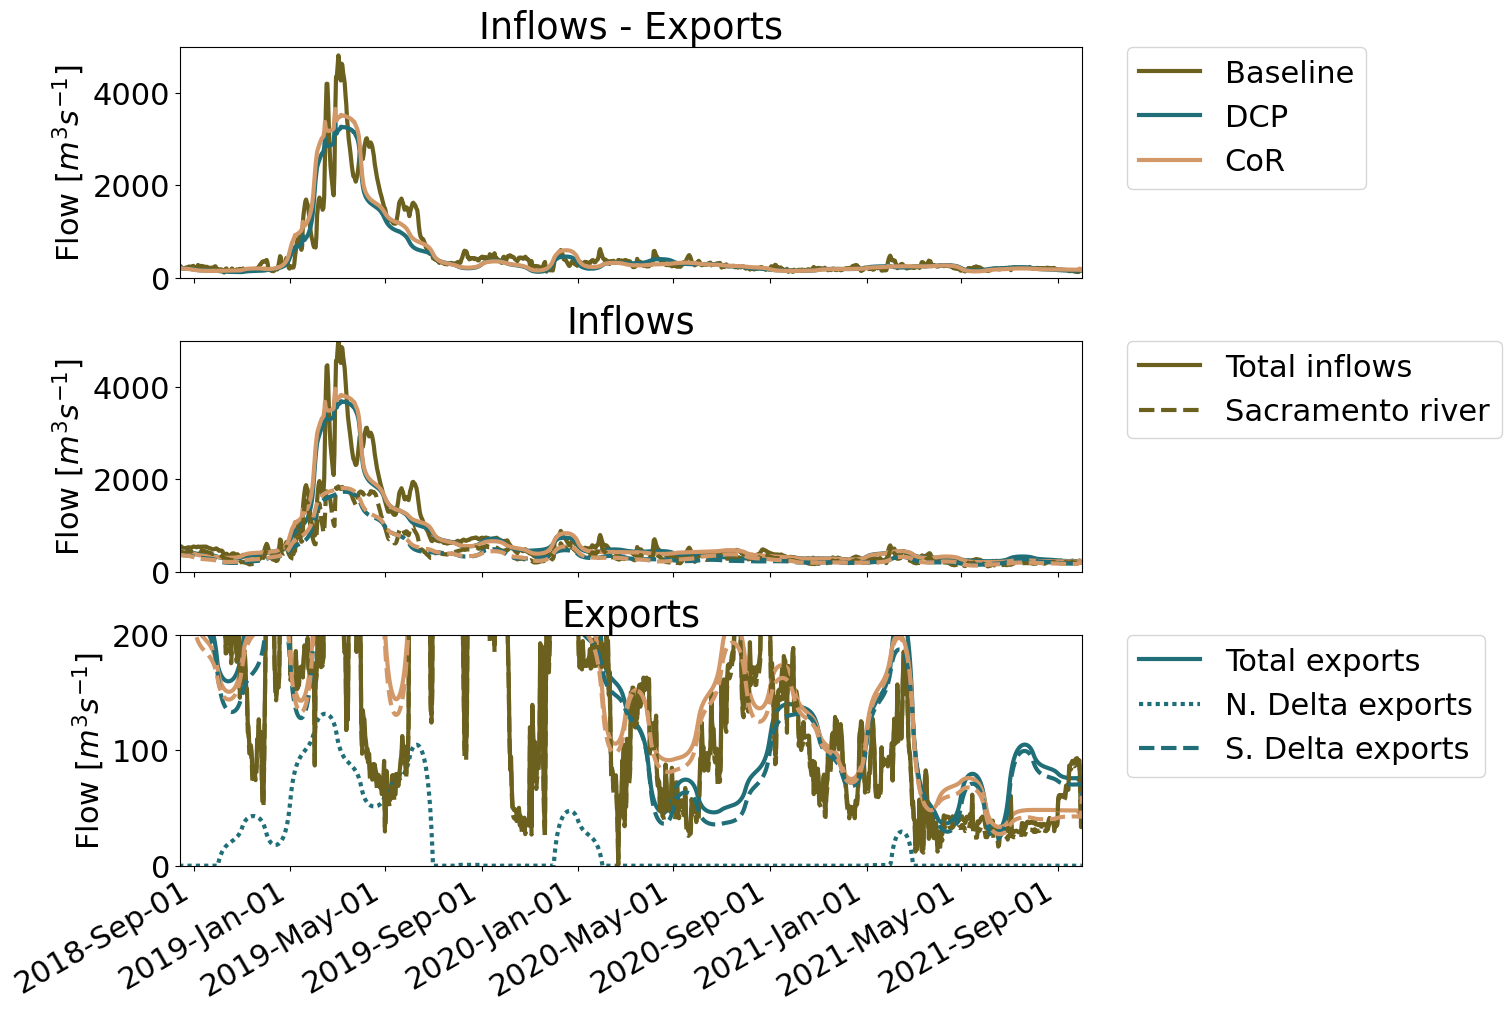

In [13]:
# zoom into the beginng of the run
# make stacked plots 
fig, ax = plt.subplots(3,figsize=(15,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,5000)
ax[0].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
ax[1].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
ax[1].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,5000)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
ax[2].plot(dcp.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
ax[2].plot(cor.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

ax[2].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-8-14"),pd.to_datetime("2021-10-1"))
ax[2].set_ylim(0,200)

ax[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2].xaxis.get_major_locator()))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/inflows_exports_scenarios_trim_feb.png')

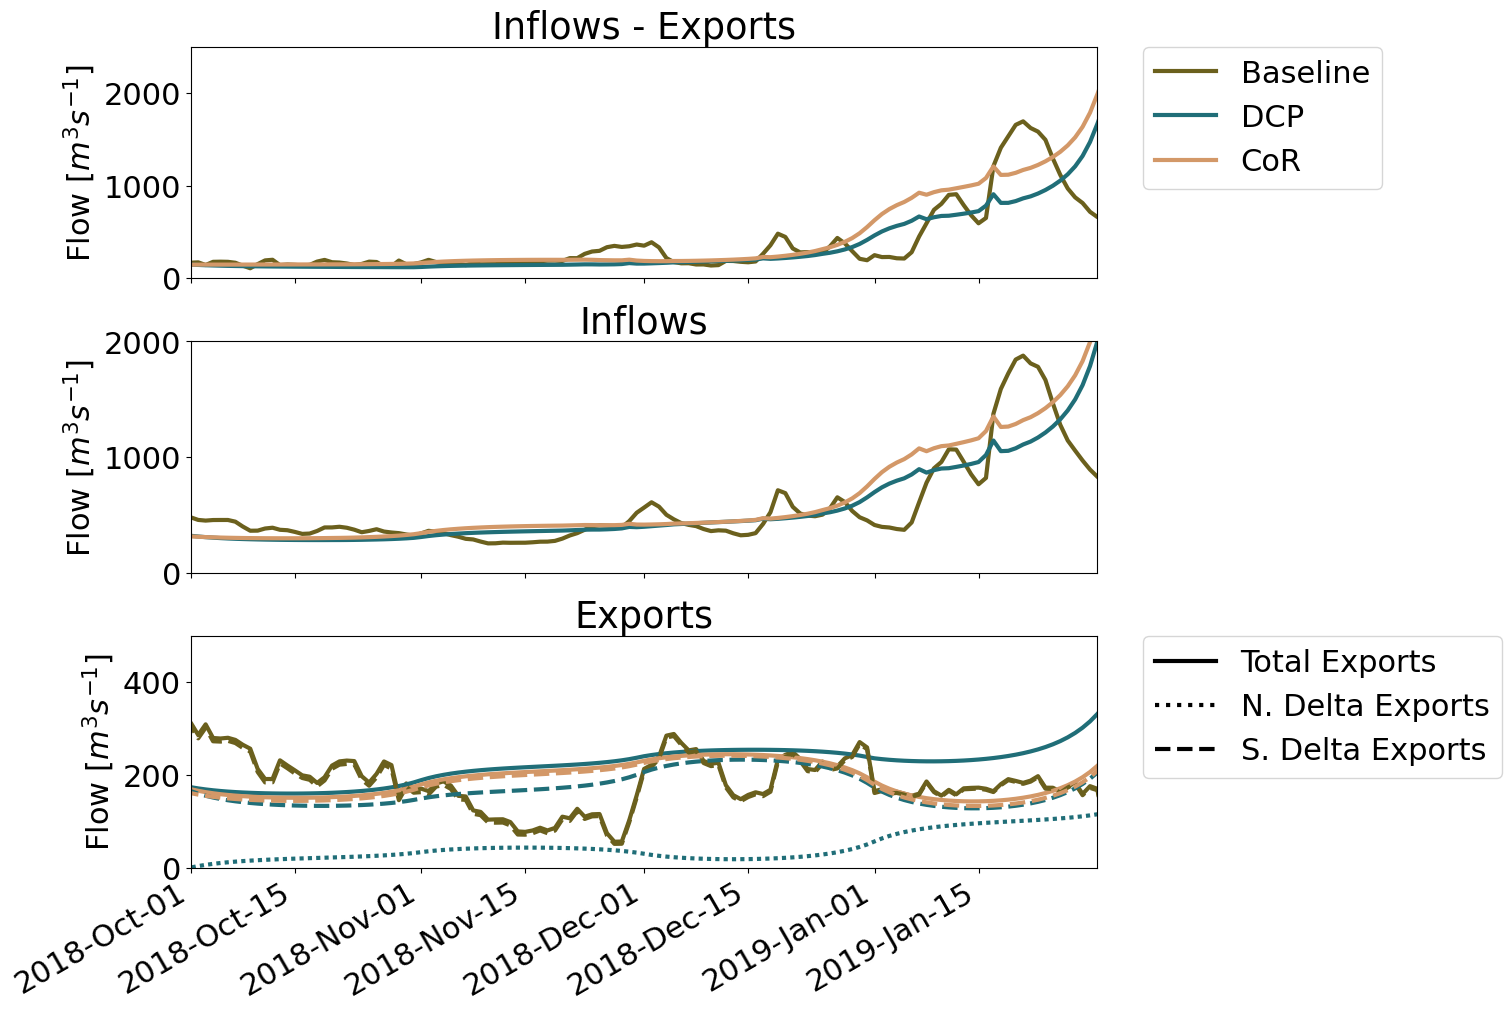

In [8]:
# make stacked plots 
fig, ax = plt.subplots(3,figsize=(15,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,2500)
ax[0].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

# ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
# ax[1].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
# ax[1].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].legend(bbox_to_anchor=(1.05, 1),
#                          loc='upper left', borderaxespad=0.)
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,2000)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
ax[2].plot(dcp.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
ax[2].plot(cor.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[2].legend(bbox_to_anchor=(1.05, 1),
#                          loc='upper left', borderaxespad=0.)

#use a patch legend
style_dict={'Total Exports':'-',
            'N. Delta Exports':':',
           'S. Delta Exports':'--'}

custom_points2=[Line2D([0], [0],linestyle=s,linewidth=3, color='k') for s in style_dict.values()]
#custom_points=custom_points1+custom_points2 # concatenate the lists

#leg = plt.legend(handles=[a,b,c,d,e,f,g],loc='upper right', bbox_to_anchor=(1.8, 2.0))
leg = ax[2].legend(custom_points2, style_dict.keys(),bbox_to_anchor=(1.05, 1),loc='upper left', borderaxespad=0.)


ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-1-31"))
ax[2].set_ylim(0,500)

ax[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2].xaxis.get_major_locator()))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3/figures/inflows_exports_scenarios_trim_feb_fix_legend.png')

In [9]:
# what are the values on Jan 8
print(base.loc[pd.to_datetime("2019-1-8")])
print(dcp.loc[pd.to_datetime("2019-1-8")])
print(cor.loc[pd.to_datetime("2019-1-8")])

coyote            -0.948750
ccc_rock           0.000000
ccc_old            0.000000
swp               83.141769
cvp              100.869690
sjr              -35.567291
calaveras          0.000000
east             -18.792187
american         -49.380939
sac             -646.301270
yolo_toedrain    -24.471041
yolo               0.000000
northbay           0.680104
napa              -3.443542
ccc_victoria       1.226771
exports          185.918335
s_exports        184.011459
inf              778.905029
net              592.986694
Name: 2019-01-08 00:00:00, dtype: float32
coyote            -0.947708
ccc_rock           0.307549
ccc_old            0.566278
swp               51.234970
cvp               84.158020
sjr              -18.332943
calaveras         -4.160078
east             -29.599979
american        -111.974716
sac             -558.160156
yolo_toedrain   -113.267403
yolo             -26.175230
northbay           7.775348
napa              -3.443865
ccc_victoria       0.315965
export

In [10]:
# what about the ratio of exports/ inflows-exports
base['ratio']=base.exports/base.net
dcp['ratio']=dcp.exports/dcp.net
cor['ratio']=cor.exports/cor.net

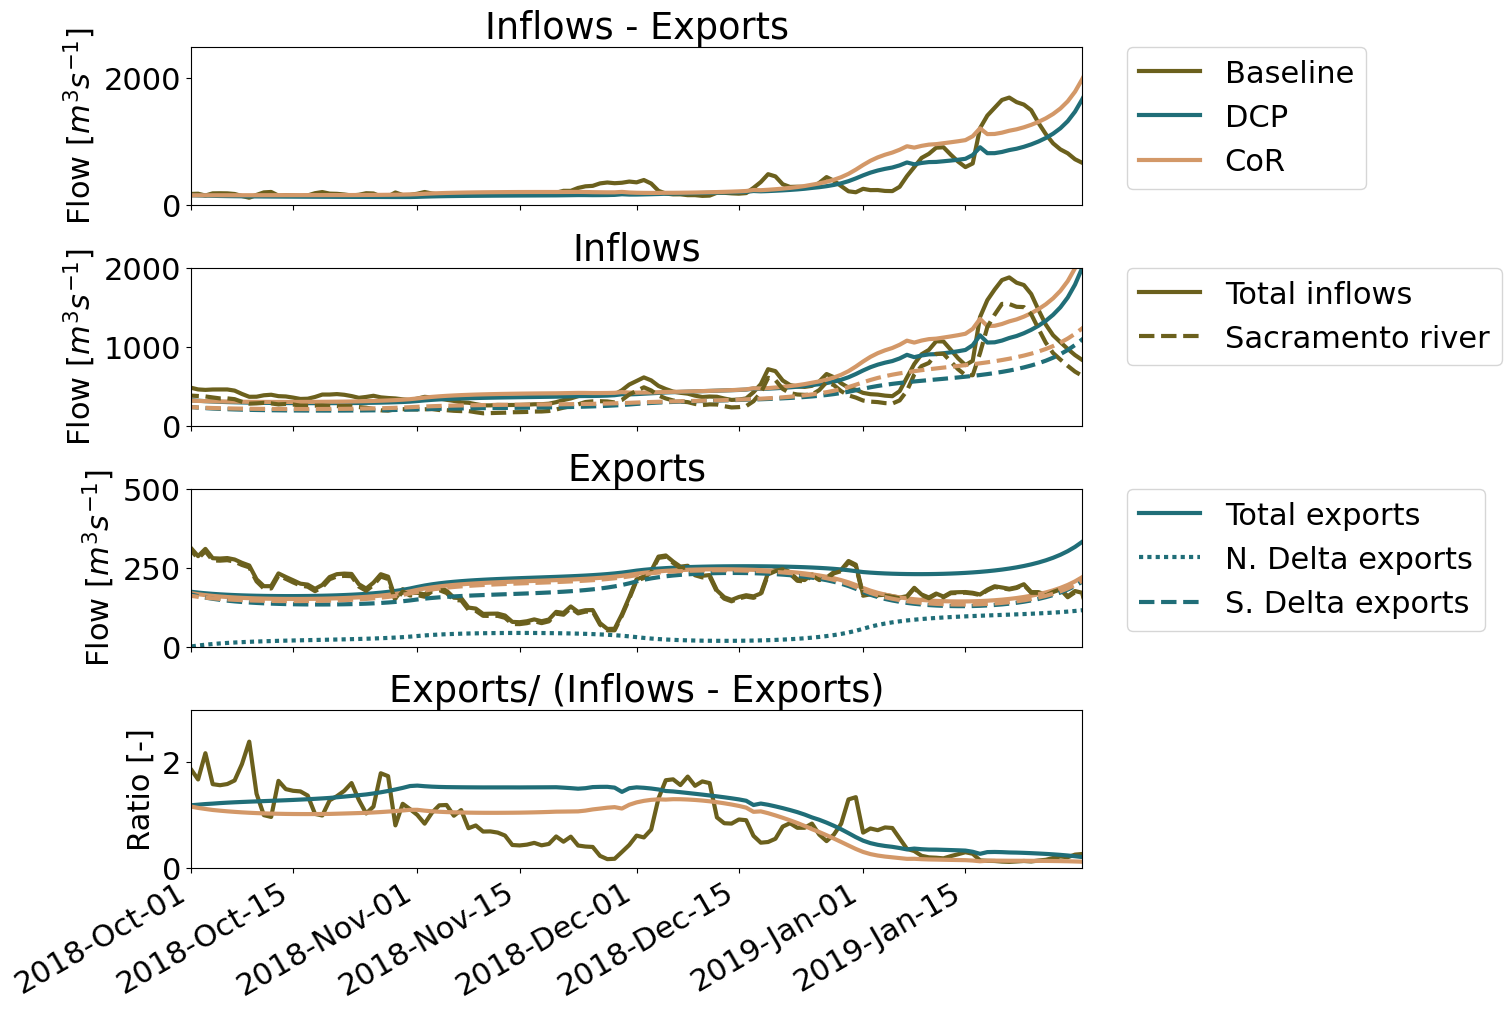

In [11]:
# make stacked plots 
fig, ax = plt.subplots(4,figsize=(15,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,2500)
ax[0].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
ax[1].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
ax[1].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,2000)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
ax[2].plot(dcp.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
ax[2].plot(cor.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

ax[2].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-1-31"))
ax[2].set_ylim(0,500)

ax[3].plot(base.ratio,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[3].plot(dcp.ratio,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[3].plot(cor.ratio,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[3].set_title('Exports/ (Inflows - Exports)')
ax[3].set_ylabel('Ratio [-]')
ax[3].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-1-31"))
ax[3].set_ylim(0,3)

ax[3].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[3].xaxis.get_major_locator()))
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[3].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

    

#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/inflows_exports_scenarios_trim_feb_ratio.png')

# compute the mean ratio of exports/ (inflows-exports) for each month

In [12]:
sdate=pd.to_datetime("2018-10-1")
edate=pd.to_datetime("2019-1-31")
months=np.unique(base[sdate:edate].index.month.values)
ratio_1=np.array([])
ratio_2=np.array([])
ratio_3=np.array([])

for m in months:
    print ('m ='+ str(m))
    b=base['ratio'][base.index.month==m][sdate:edate].dropna().mean()
    print('baseline mean ratio = '+str(b))
    ratio_1=np.append(ratio_1,b)
    d=dcp['ratio'][dcp.index.month==m][sdate:edate].dropna().mean()
    print('dcp mean ratio = '+str(d))
    ratio_2=np.append(ratio_2,d)
    c=cor['ratio'][cor.index.month==m][sdate:edate].dropna().mean()
    print('cor mean ratio = '+str(c))
    ratio_3=np.append(ratio_3,c)
    

m =1
baseline mean ratio = 0.28992313146591187
dcp mean ratio = 0.3180719316005707
cor mean ratio = 0.15273036062717438
m =10
baseline mean ratio = 1.453898310661316
dcp mean ratio = 1.3162277936935425
cor mean ratio = 1.0518689155578613
m =11
baseline mean ratio = 0.6095077991485596
dcp mean ratio = 1.5218530893325806
cor mean ratio = 1.0719521045684814
m =12
baseline mean ratio = 0.9799243211746216
dcp mean ratio = 1.1938683986663818
cor mean ratio = 1.016601800918579


In [13]:
# concatenate these together and write to csv
ratio_stack=np.vstack((ratio_1,ratio_2,ratio_3))
df_ratio=pd.DataFrame(data=ratio_stack,columns=months)
df_ratio

,1,10,11,12
0,0.289923,1.453898,0.609508,0.979924
1,0.318072,1.316228,1.521853,1.193868
2,0.152730,1.051869,1.071952,1.016602


In [14]:
#df_ratio.to_csv('./ratio_exports_all_scenarios_2026_04_14.csv',index=False)

# repeat for mean monthly exports

In [15]:
sdate=pd.to_datetime("2018-10-1")
edate=pd.to_datetime("2019-1-31")
months=np.unique(base[sdate:edate].index.month.values)
exports_1=np.array([])
exports_2=np.array([])
exports_3=np.array([])

for m in months:
    print ('m ='+ str(m))
    b=base['exports'][base.index.month==m][sdate:edate].dropna().mean()
    print('baseline mean exports = '+str(b))
    exports_1=np.append(exports_1,b)
    d=dcp['exports'][dcp.index.month==m][sdate:edate].dropna().mean()
    print('dcp mean exports = '+str(d))
    exports_2=np.append(exports_2,d)
    c=cor['exports'][cor.index.month==m][sdate:edate].dropna().mean()
    print('cor mean exports = '+str(c))
    exports_3=np.append(exports_3,c)
    

m =1
baseline mean exports = 171.45098876953125
dcp mean exports = 249.60052490234375
cor mean exports = 161.20559692382812
m =10
baseline mean exports = 226.50625610351562
dcp mean exports = 165.5597686767578
cor mean exports = 157.1020965576172
m =11
baseline mean exports = 115.19841766357422
dcp mean exports = 215.74432373046875
cor mean exports = 205.61419677734375
m =12
baseline mean exports = 222.23890686035156
dcp mean exports = 249.93174743652344
cor mean exports = 234.34161376953125


In [16]:
# concatenate these together and write to csv
exports_stack=np.vstack((exports_1,exports_2,exports_3))
df_exports=pd.DataFrame(data=exports_stack,columns=months)
df_exports

,1,10,11,12
0,171.450989,226.506256,115.198418,222.238907
1,249.600525,165.559769,215.744324,249.931747
2,161.205597,157.102097,205.614197,234.341614


In [17]:
df_exports.to_csv('./exports_all_scenarios_2026_04_17.csv',index=False)

In [18]:
import matplotlib.dates as mdates

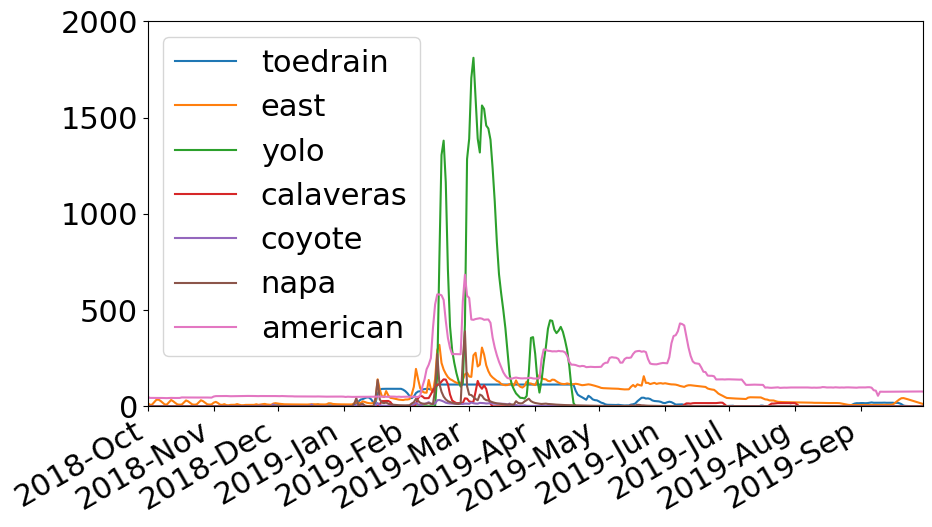

In [19]:
# what is the rest of the peak inflows for the basecase
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(base.yolo_toedrain*-1,label='toedrain')
ax.plot(base.east*-1,label='east')
ax.plot(base['yolo']*-1,label='yolo')
ax.plot(base['calaveras']*-1,label='calaveras')
ax.plot(base['coyote']*-1,label='coyote')
ax.plot(base['napa']*-1,label='napa')
ax.plot(base['american']*-1,label='american')
ax.set_ylim(0,2000)
ax.legend()
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

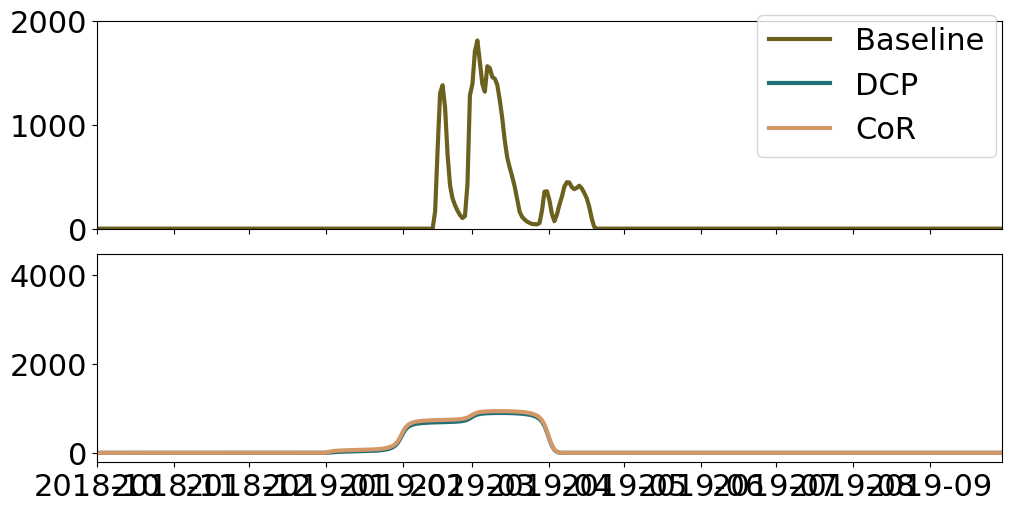

In [20]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.yolo*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.yolo*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.yolo*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,2000)
fig.legend()

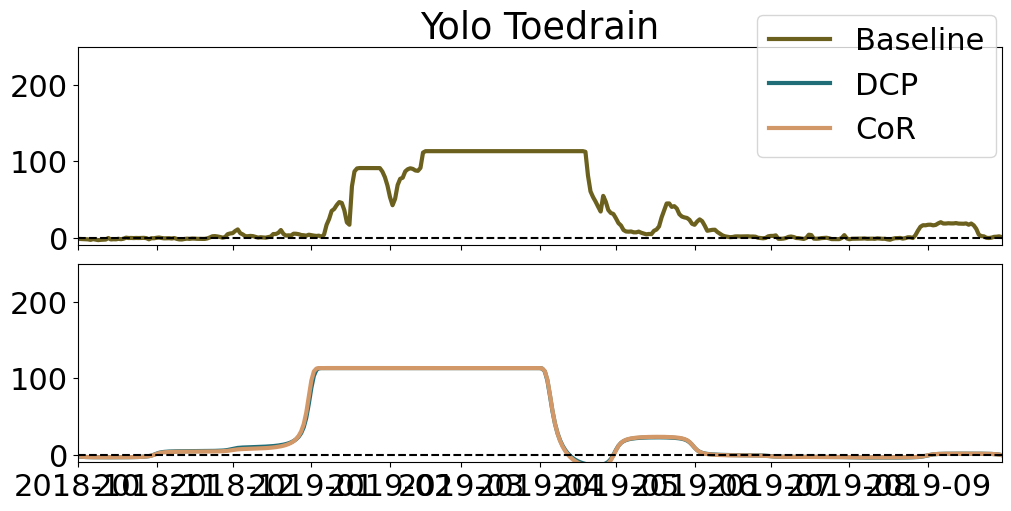

In [21]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.yolo_toedrain*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.yolo_toedrain*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.yolo_toedrain*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,250)
ax[1].set_ylim(-10,250)
ax[0].set_title('Yolo Toedrain')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

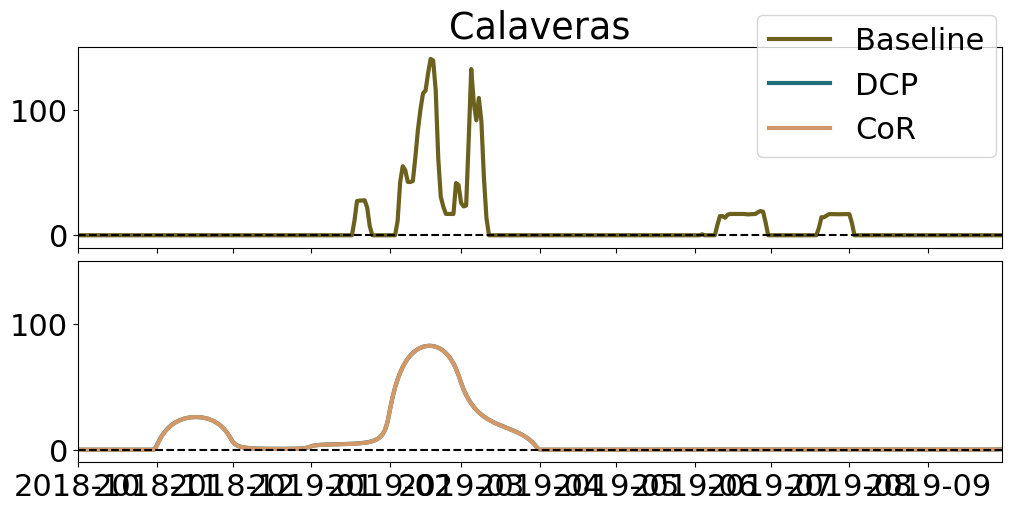

In [22]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.calaveras*-1, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.calaveras*-1, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.calaveras*-1, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,150)
ax[1].set_ylim(-10,150)
ax[0].set_title('Calaveras')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

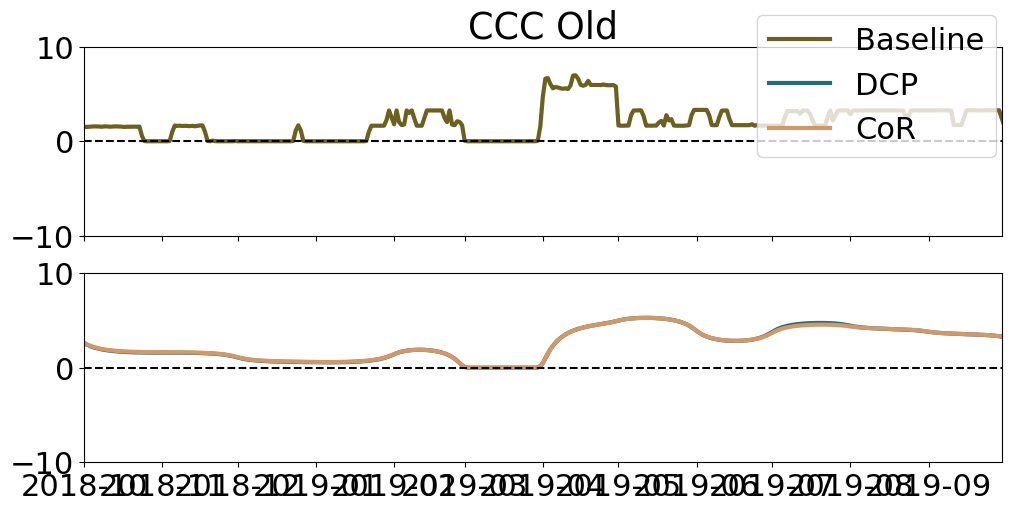

In [23]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.ccc_old, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.ccc_old, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.ccc_old, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,10)
ax[1].set_ylim(-10,10)
ax[0].set_title('CCC Old')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()

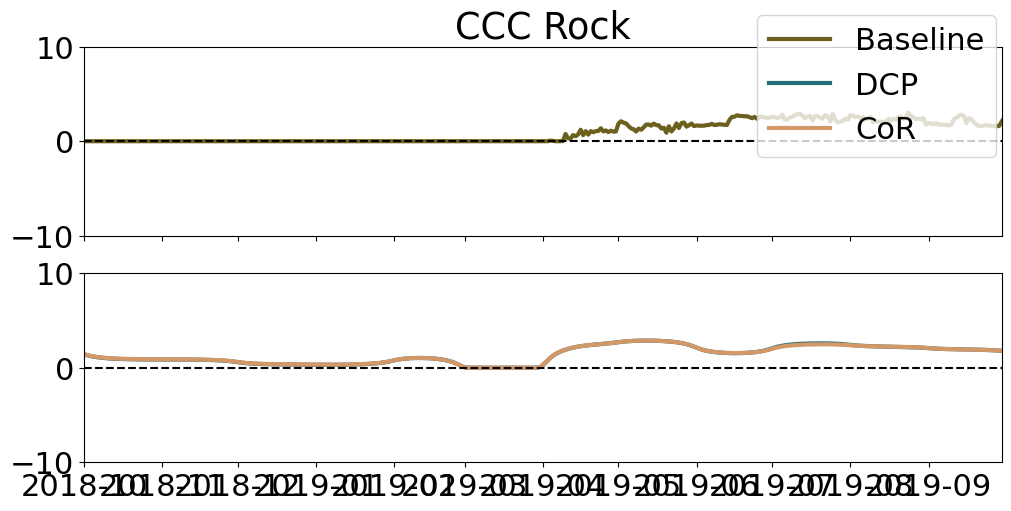

In [24]:
fig, ax = plt.subplots(2,figsize=(10,5),sharex=True,layout='constrained')
ax[0].plot(base.ccc_rock, linewidth=3,label='Baseline',color=cmocean.cm.tarn(1/6))
ax[1].plot(dcp.ccc_rock, linewidth=3,label='DCP',color=cmocean.cm.tarn(10/12))
ax[1].plot(cor.ccc_rock, linewidth=3,label='CoR',color=cmocean.cm.tarn(2/6))
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(-10,10)
ax[1].set_ylim(-10,10)
ax[0].set_title('CCC Rock')
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
fig.legend()